#Purpose 
#1. placement_status – Indicates whether the student is placed or not (Classification target)
#2. salary_package_lpa – Salary offered in Lakhs Per Annum (Regression target)

#Progress
#data clean→EDA→feature selection→create model→iterate→validate

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Student Placement Prediction Dataset 2026.csv")

In [5]:
df.head(10)

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16
5,6,22,Male,7.44,CSE,Tier 2,1,5,1,49.758865,...,66.138578,82.038139,0,54.150818,69.210022,No,9.1,3.4,Placed,11.78
6,7,22,Male,7.54,CSE,Tier 3,0,2,2,68.816160,...,56.207496,72.267945,1,79.323137,26.179746,No,8.9,3.1,Not Placed,0.00
7,8,24,Female,6.86,Civil,Tier 3,3,4,2,87.471971,...,89.189601,79.128528,1,23.394036,36.903695,Yes,8.8,1.6,Not Placed,0.00
8,9,19,Male,8.52,Mechanical,Tier 2,2,5,0,100.000000,...,64.035703,89.884948,0,68.598878,42.647145,No,8.5,4.2,Placed,16.33
9,10,20,Female,8.07,Civil,Tier 2,2,2,2,93.421972,...,72.217117,88.901107,0,86.199176,1.371853,No,5.9,4.5,Placed,16.17


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

In [7]:
df.isna().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
# I don't need this
df_clean = df.drop('student_id', axis=1)
df_clean.head(10)

,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,81.707722,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,63.116715,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,48.658753,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,66.376653,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,61.274985,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16
5,22,Male,7.44,CSE,Tier 2,1,5,1,49.758865,45.252593,...,66.138578,82.038139,0,54.150818,69.210022,No,9.1,3.4,Placed,11.78
6,22,Male,7.54,CSE,Tier 3,0,2,2,68.816160,63.787196,...,56.207496,72.267945,1,79.323137,26.179746,No,8.9,3.1,Not Placed,0.00
7,24,Female,6.86,Civil,Tier 3,3,4,2,87.471971,56.962395,...,89.189601,79.128528,1,23.394036,36.903695,Yes,8.8,1.6,Not Placed,0.00
8,19,Male,8.52,Mechanical,Tier 2,2,5,0,100.000000,93.987115,...,64.035703,89.884948,0,68.598878,42.647145,No,8.5,4.2,Placed,16.33
9,20,Female,8.07,Civil,Tier 2,2,2,2,93.421972,71.379374,...,72.217117,88.901107,0,86.199176,1.371853,No,5.9,4.5,Placed,16.17


In [10]:
# If I use get dummies, Multicollinearity will slow down the model.
df_clean['college_tier'] = df_clean['college_tier'].str.replace('Tier ', '').astype(int)
df_clean.head(10)

,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,24,Male,7.53,IT,2,4,6,1,99.238568,81.707722,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,21,Male,7.92,CSE,2,1,3,6,80.966123,63.116715,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,22,Female,8.60,EEE,1,0,1,1,49.177184,48.658753,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,24,Male,6.68,CSE,1,0,2,2,79.359084,66.376653,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,20,Female,8.43,IT,3,1,4,3,65.018573,61.274985,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16
5,22,Male,7.44,CSE,2,1,5,1,49.758865,45.252593,...,66.138578,82.038139,0,54.150818,69.210022,No,9.1,3.4,Placed,11.78
6,22,Male,7.54,CSE,3,0,2,2,68.816160,63.787196,...,56.207496,72.267945,1,79.323137,26.179746,No,8.9,3.1,Not Placed,0.00
7,24,Female,6.86,Civil,3,3,4,2,87.471971,56.962395,...,89.189601,79.128528,1,23.394036,36.903695,Yes,8.8,1.6,Not Placed,0.00
8,19,Male,8.52,Mechanical,2,2,5,0,100.000000,93.987115,...,64.035703,89.884948,0,68.598878,42.647145,No,8.5,4.2,Placed,16.33
9,20,Female,8.07,Civil,2,2,2,2,93.421972,71.379374,...,72.217117,88.901107,0,86.199176,1.371853,No,5.9,4.5,Placed,16.17


In [11]:
# No tier and only 2 situation in gender, volunteer_experience and placement_status, so map. 
# Branch get dummies
df_clean['gender'] = df_clean['gender'].map({'Male': 1, 'Female': 0})

df_clean['volunteer_experience'] = df_clean['volunteer_experience'].map({
    'Yes': 1, 
    'No': 0
})

df_clean['placement_status'] = df_clean['placement_status'].map({
    'Placed': 1, 
    'Not Placed': 0
})

df_clean = pd.get_dummies(
    df_clean, 
    columns=['branch'],          
    drop_first=True,             
    prefix='branch',             
    dtype=int                    
)

In [12]:
df_clean.head(10)

,age,gender,cgpa,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,...,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa,branch_Civil,branch_ECE,branch_EEE,branch_IT,branch_Mechanical
0,24,1,7.53,2,4,6,1,99.238568,81.707722,57.707166,...,1,6.7,3.6,0,0.00,0,0,0,1,0
1,21,1,7.92,2,1,3,6,80.966123,63.116715,59.197085,...,0,4.4,2.3,0,0.00,0,0,0,0,0
2,22,0,8.60,1,0,1,1,49.177184,48.658753,92.104885,...,0,8.8,5.9,1,11.99,0,0,1,0,0
3,24,1,6.68,1,0,2,2,79.359084,66.376653,83.411798,...,1,8.1,4.4,0,0.00,0,0,0,0,0
4,20,0,8.43,3,1,4,3,65.018573,61.274985,88.956331,...,0,8.7,3.4,1,12.16,0,0,0,1,0
5,22,1,7.44,2,1,5,1,49.758865,45.252593,51.881728,...,0,9.1,3.4,1,11.78,0,0,0,0,0
6,22,1,7.54,3,0,2,2,68.816160,63.787196,79.969910,...,0,8.9,3.1,0,0.00,0,0,0,0,0
7,24,0,6.86,3,3,4,2,87.471971,56.962395,58.138781,...,1,8.8,1.6,0,0.00,1,0,0,0,0
8,19,1,8.52,2,2,5,0,100.000000,93.987115,75.165144,...,0,8.5,4.2,1,16.33,0,0,0,0,1
9,20,0,8.07,2,2,2,2,93.421972,71.379374,57.215196,...,0,5.9,4.5,1,16.17,1,0,0,0,0


In [13]:
# heatmap 

numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])

important_cols = [
    'cgpa', 'internships_count', 'projects_count', 'certifications_count',
    'coding_skill_score', 'aptitude_score', 'communication_skill_score',
    'logical_reasoning_score', 'mock_interview_score', 'attendance_percentage',
    'backlogs', 'extracurricular_score', 'leadership_score',
    'gender', 'volunteer_experience']

#filter

important_cols = [col for col in important_cols if col in numeric_df.columns]

corr = numeric_df[important_cols].corr()

In [14]:
cols_for_placement = important_cols + ['placement_status']
corr_placement = df_clean[cols_for_placement].corr()

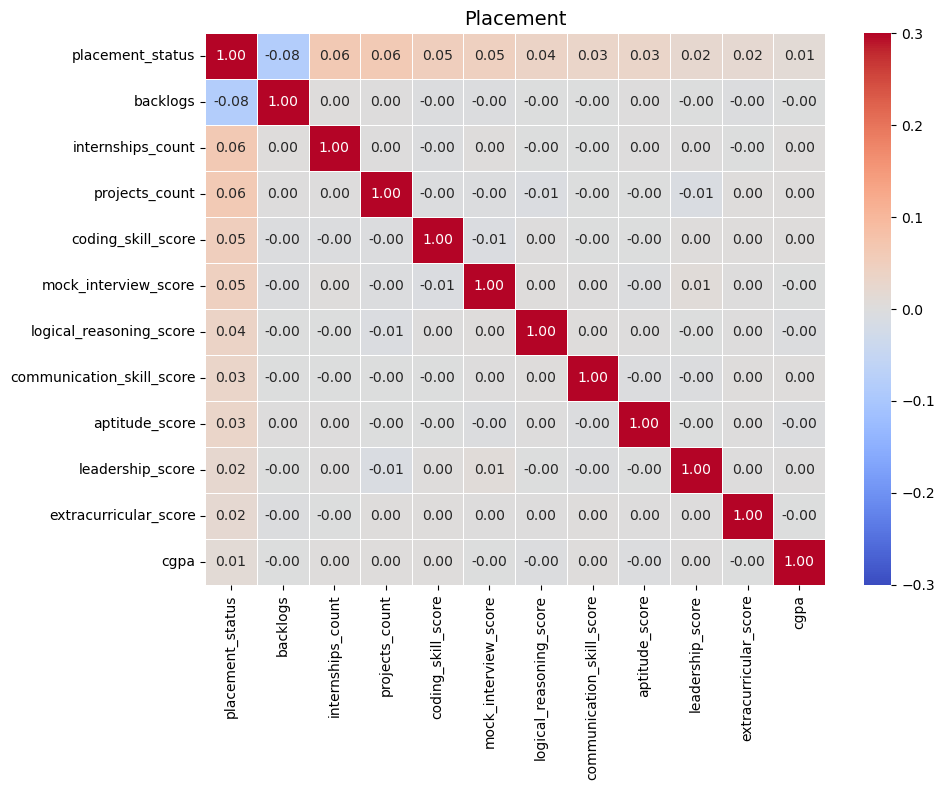


 placement_status （first 12）：
placement_status             1.000000
internships_count            0.063489
projects_count               0.060964
coding_skill_score           0.050773
mock_interview_score         0.046058
logical_reasoning_score      0.036332
communication_skill_score    0.032242
aptitude_score               0.031690
leadership_score             0.022170
extracurricular_score        0.020100
cgpa                         0.012067
gender                       0.001244
Name: placement_status, dtype: float64


In [15]:
top_placement = corr_placement['placement_status'].abs().sort_values(ascending=False).head(12).index
corr_placement_top = corr_placement.loc[top_placement, top_placement]

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_placement_top,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-0.3, vmax=0.3,   
    center=0
)
plt.title('Placement', fontsize=14)
plt.tight_layout()
plt.show()

print("\n placement_status （first 12）：")
print(corr_placement['placement_status'].sort_values(ascending=False).head(12))

#none obvious linear regresiion relationshop between each factors except salary

In [16]:
# all not placed studens have 0 salary
placed_df = df_clean[df_clean['placement_status'] == 1].copy()

cols_for_salary = important_cols + ['salary_package_lpa']
corr_salary = placed_df[cols_for_salary].corr()

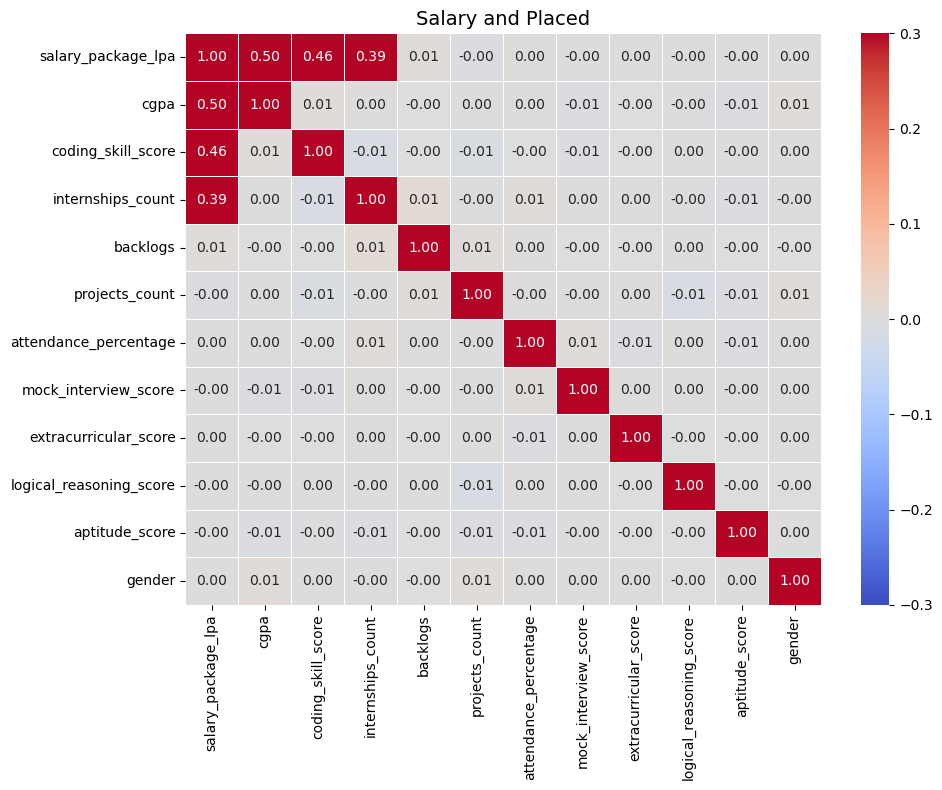


 salary_package_lpa （first 12）：
salary_package_lpa           1.000000
cgpa                         0.498746
coding_skill_score           0.455421
internships_count            0.391642
backlogs                     0.008450
attendance_percentage        0.004092
extracurricular_score        0.003334
gender                       0.002853
certifications_count         0.002352
volunteer_experience         0.001191
leadership_score             0.000722
communication_skill_score   -0.000231
Name: salary_package_lpa, dtype: float64


In [17]:
top_salary = corr_salary['salary_package_lpa'].abs().sort_values(ascending=False).head(12).index
corr_salary_top = corr_salary.loc[top_salary, top_salary]

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_salary_top,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-0.3, vmax=0.3,
    center=0
)
plt.title(('Salary and Placed'), fontsize=14)
plt.tight_layout()
plt.show()

print("\n salary_package_lpa （first 12）：")
print(corr_salary['salary_package_lpa'].sort_values(ascending=False).head(12))

placement_status
1    0.54459
0    0.45541
Name: proportion, dtype: float64


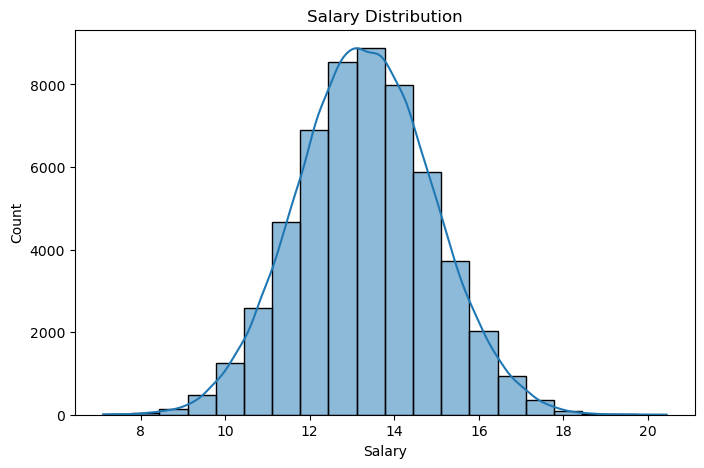

In [18]:
# check distribution
print(df_clean['placement_status'].value_counts(normalize=True))

placed_df = df_clean[df_clean['placement_status'] == 1]
plt.figure(figsize=(8, 5))
sns.histplot(placed_df['salary_package_lpa'], kde=True, bins=20)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.show()

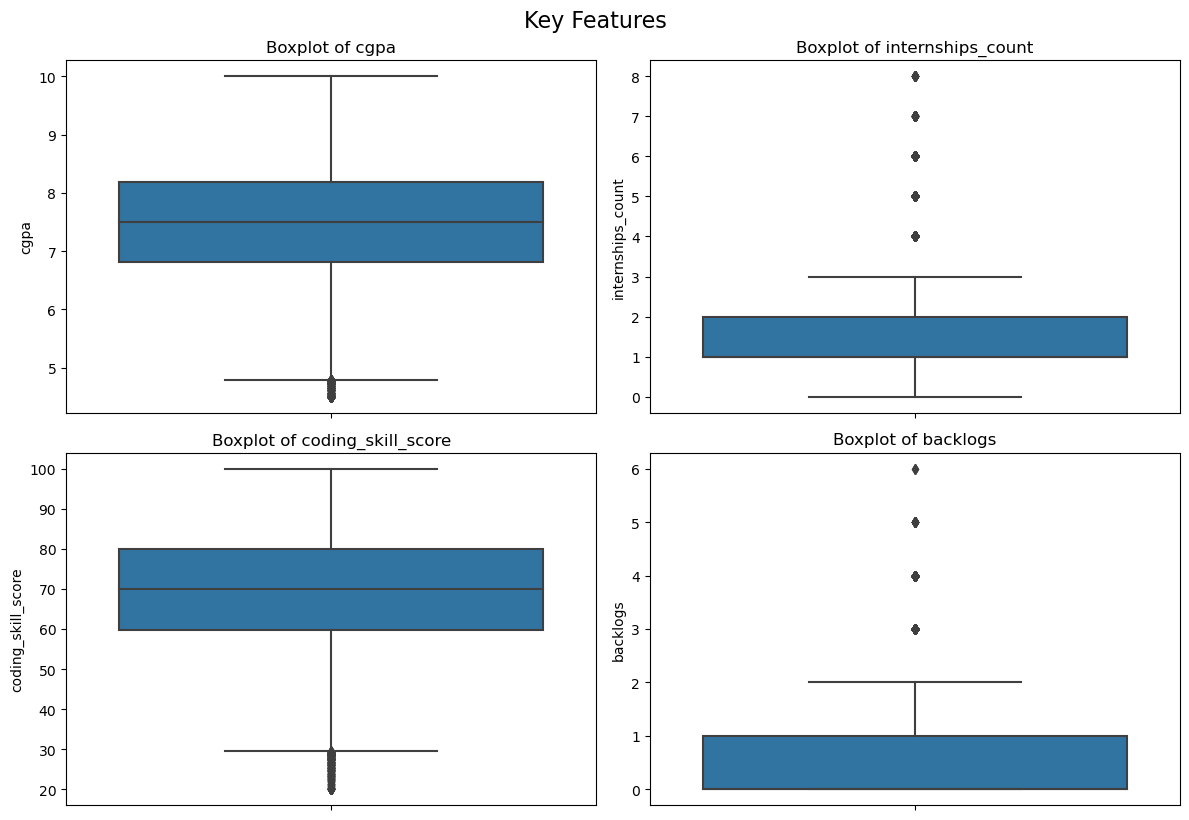

In [19]:
features_to_check = ['cgpa', 'internships_count', 'coding_skill_score', 'backlogs']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8)) 
axes = axes.flatten()

for i, feat in enumerate(features_to_check):
    sns.boxplot(y=df_clean[feat], ax=axes[i])
    axes[i].set_title(f'Boxplot of {feat}')
    axes[i].set_ylabel(feat)
    
# no outlier for important features

plt.tight_layout()
plt.suptitle('Key Features', fontsize=16, y=1.02)
plt.show()

In [20]:
print(df_clean['college_tier'].value_counts(normalize=True))
branch_cols = [col for col in df_clean.columns if col.startswith('branch_')]
print(df_clean[branch_cols].sum() / len(df_clean))

# both a little imbalance

college_tier
2    0.49955
3    0.29884
1    0.20161
Name: proportion, dtype: float64
branch_Civil         0.10021
branch_ECE           0.14908
branch_EEE           0.10177
branch_IT            0.19999
branch_Mechanical    0.10077
dtype: float64


In [21]:
# 1. placement_status – Indicates whether the student is placed or not (Classification target)

X = df_clean.drop(['placement_status', 'salary_package_lpa'], axis=1)
y = df_clean['placement_status']

# drop salary to avoid target leakage

In [22]:
# Xgboost

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

In [26]:
cv_params = {
    'n_estimators':     [100, 200, 300],          
    'max_depth':        [4, 6, 8],                 
    'learning_rate':    [0.05, 0.1, 0.2],          
    'subsample':        [0.7, 0.8, 1.0],           
    'colsample_bytree': [0.7, 0.8, 1.0],           
    'scale_pos_weight': [(y_train == 0).sum() / (y_train == 1).sum()]  }

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    nthread=4,
    verbosity=0,)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=cv_params,
    n_iter=15,               
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    random_state=42,
    n_jobs=1)


print("Starting RandomizedSearchCV...")
random_search.fit(X_train, y_train)
print("\nBest parameters found:")
print(random_search.best_params_)
print("\nBest ROC AUC score (CV):", f"{random_search.best_score_:.4f}")#
# I don't use random at first, but my cpu dead. 

Starting RandomizedSearchCV...
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best parameters found:
{'subsample': 0.8, 'scale_pos_weight': 0.836249729963275, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best ROC AUC score (CV): 0.5831


In [27]:
best_model = random_search.best_estimator_

y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== Test Set Performance ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_proba))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


=== Test Set Performance ===
Accuracy: 0.5512
ROC AUC: 0.577446417709448

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.53      0.52      6831
           1       0.59      0.57      0.58      8169

    accuracy                           0.55     15000
   macro avg       0.55      0.55      0.55     15000
weighted avg       0.55      0.55      0.55     15000



In [28]:
# test baseline since 57% like my model didn't learn anything

from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print("Dummy (most frequent) Test Accuracy:", accuracy_score(y_test, dummy.predict(X_test)))

# OK, it truly didn't learn

Dummy (most frequent) Test Accuracy: 0.5446


In [29]:
#let's do feature engineering


df_clean['internships_ge2']   = (df_clean['internships_count'] >= 2).astype(int)
df_clean['internships_ge3']   = (df_clean['internships_count'] >= 3).astype(int)
df_clean['projects_ge2']      = (df_clean['projects_count'] >= 2).astype(int)


df_clean['has_backlogs']      = (df_clean['backlogs'] > 0).astype(int)
df_clean['backlogs_ge2']      = (df_clean['backlogs'] >= 2).astype(int)


df_clean['cgpa_ge75']         = (df_clean['cgpa'] >= 7.5).astype(int)
df_clean['cgpa_ge80']         = (df_clean['cgpa'] >= 8.0).astype(int)
df_clean['cgpa_ge85']         = (df_clean['cgpa'] >= 8.5).astype(int)

skill_cols = [
    'coding_skill_score',
    'aptitude_score',
    'logical_reasoning_score',
    'communication_skill_score',
    'mock_interview_score'
]

# drawbacks
df_clean['skill_avg']   = df_clean[skill_cols].mean(axis=1)
df_clean['skill_sum']   = df_clean[skill_cols].sum(axis=1)
df_clean['skill_min']   = df_clean[skill_cols].min(axis=1)   # 最弱的一項可能決定成敗
df_clean['skill_std']   = df_clean[skill_cols].std(axis=1)   # 分數是否均衡

# good skills
df_clean['high_skill_count_70'] = (df_clean[skill_cols] >= 70).sum(axis=1)
df_clean['high_skill_count_80'] = (df_clean[skill_cols] >= 80).sum(axis=1)

# CGPA × skills
df_clean['cgpa_x_coding']      = df_clean['cgpa'] * df_clean['coding_skill_score']
df_clean['cgpa_x_mock']        = df_clean['cgpa'] * df_clean['mock_interview_score']

# project+intern
df_clean['intern_project_interact'] = df_clean['internships_count'] * df_clean['projects_count']

# intern +backlig
df_clean['intern_no_backlog']  = df_clean['internships_ge2'] * (1 - df_clean['has_backlogs'])

In [30]:
X_new = df_clean.drop(['placement_status', 'salary_package_lpa'], axis=1)
y_new = df_clean['placement_status']
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new,
    test_size=0.15,
    random_state=42,
    stratify=y_new
)

random_search.fit(X_train_new, y_train_new)


print("\nNew Best ROC AUC score (CV):", f"{random_search.best_score_:.4f}")

# not changed a lot after feature engineering

Fitting 5 folds for each of 15 candidates, totalling 75 fits

New Best ROC AUC score (CV): 0.5824


**Model Performance Summary**
The model performed very poorly (ROC AUC ≈ 0.58, close to random guessing).

**Key Insight**
Feature correlations with placement_status are extremely weak (maximum only ~0.06). Even after extensive feature engineering.

**Core Understanding**  
School performance alone (CGPA, internships, projects, skill scores, backlogs, etc.) cannot reliably predict placement outcome in the job market.

**Application to Education**  
Academic grades and skill scores are not dependable indicators of real-world workplace competitiveness. Employers likely prioritise interview performance, company preferences, referrals, internship quality, and other off-campus factors over pure academic metrics.

**Reality from the Data**  
School performance ≠ job market success.  

In [32]:
placed_df = df_clean[df_clean['placement_status'] == 1].copy()
#only placed students get salary

In [42]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [35]:
X_reg = placed_df.drop(['placement_status', 'salary_package_lpa'], axis=1)
y_reg = placed_df['salary_package_lpa']

In [36]:
X_temp, X_test_r, y_temp, y_test_r = train_test_split(
    X_reg, y_reg,
    test_size=0.15,
    random_state=42
)

X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,  # ≈15% of total
    random_state=42
)

print("Train size:", len(X_train_r))
print("Validation size:", len(X_val_r))
print("Test size:", len(X_test_r))

Train size: 38119
Validation size: 8171
Test size: 8169


In [40]:
cv_params_2 = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_reg_base = XGBRegressor(
    random_state=42,
    verbosity=0,
    nthread=4          )

random_search_reg = RandomizedSearchCV(
    estimator=xgb_reg_base,
    param_distributions=cv_params_2,
    n_iter=30,                   
    scoring='r2',                
    cv=3,                        
    verbose=1,
    random_state=42,
    n_jobs=4                     
)

print("Starting RandomizedSearchCV for Salary Regression...")
random_search_reg.fit(X_train_r, y_train_r)

print("\nBest parameters found:")
print(random_search_reg.best_params_)

print("\nBest R² score (CV):")
print(f"{random_search_reg.best_score_:.4f}")

Starting RandomizedSearchCV for Salary Regression...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best parameters found:
{'subsample': 0.7, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best R² score (CV):
0.6044



=== Validation Set Performance ===
MSE: 0.997778207864114
R²: 0.6085088058405356

=== Test Set Performance (Final) ===
MSE: 1.0071316330166467
R²: 0.5994918099188129

Top 10 Feature Importances for Salary:
internships_ge2            0.226852
cgpa_ge80                  0.181415
cgpa_x_coding              0.162340
cgpa_ge75                  0.148378
internships_ge3            0.142753
internships_count          0.053098
cgpa                       0.033949
cgpa_ge85                  0.010660
coding_skill_score         0.002512
intern_project_interact    0.002065
dtype: float32


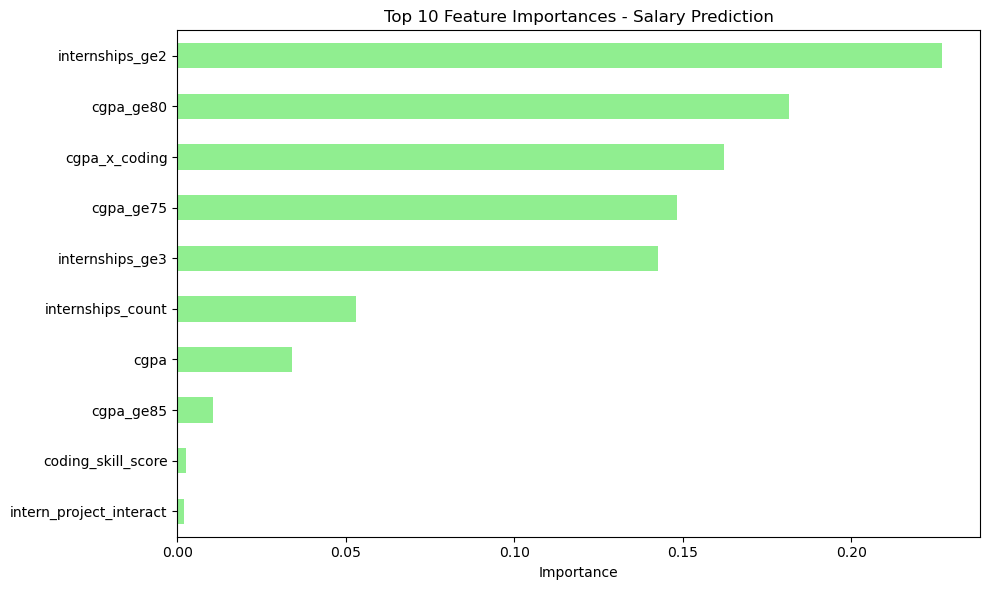

In [44]:
best_reg_model = random_search_reg.best_estimator_

y_val_pred = best_reg_model.predict(X_val_r)
print("\n=== Validation Set Performance ===")
print("MSE:", mean_squared_error(y_val_r, y_val_pred))
print("R²:", r2_score(y_val_r, y_val_pred))

y_test_pred = best_reg_model.predict(X_test_r)
print("\n=== Test Set Performance (Final) ===")
print("MSE:", mean_squared_error(y_test_r, y_test_pred))
print("R²:", r2_score(y_test_r, y_test_pred))

importances_reg = pd.Series(
    best_reg_model.feature_importances_,
    index=X_reg.columns
).sort_values(ascending=False)

print("\nTop 10 Feature Importances for Salary:")
print(importances_reg.head(10))

# Plot top 10
plt.figure(figsize=(10, 6))
importances_reg.head(10).plot(kind='barh', color='lightgreen')
plt.title('Top 10 Feature Importances - Salary Prediction')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Model Performance**
Solid result: Test R² ≈ 0.60, Validation R² ≈ 0.61 (explains ~60% of salary variance).

**Key Insight**
Top drivers of higher salary:

Multiple internships (internships_ge2 ≥ 2) – strongest factor
High CGPA thresholds (≥7.5–8.0)
CGPA × coding skill interaction

**Real-World Implication**
Practical experience (multiple internships) matters more than grades alone for salary.
High CGPA and coding skills help, but only when paired with proven real-world readiness.